# UYGULAMALI ZAMAN SERİLERİ
## DÖNEM ÖDEVİ
### 2025-2026 GÜZ DÖNEMİ
### DÖNEM SONU ÖDEVİ

**Konu:** Türkiye Elektrik Üretim ve Tüketim Serilerinde Mevsimsellik ve Trend Ayrıştırması (TEİAŞ)
**Hazırlayan:** (Öğrenci No) Ad Soyad  
**E-posta:** name.surname@...  
**Dersi Veren:** Prof. Dr. Ali Hakan Büyüklü

---

## 1. Giriş ve Amaç

Enerji talebinin doğru tahmin edilmesi, enerji arz güvenliğinin sağlanması, yatırım planlaması ve piyasa operasyonlarının verimliliği açısından kritik öneme sahiptir. Elektrik, depolanması zor ve maliyetli bir emtia olduğundan, üretim ve tüketim dengesinin anlık olarak sağlanması gerekmektedir. Bu dengeyi sağlamak için kısa, orta ve uzun vadeli talep tahminlerine ihtiyaç duyulmaktadır.

Bu çalışmanın temel amacı, Türkiye Elektrik İletim A.Ş. (TEİAŞ) tarafından sağlanan aylık elektrik üretim verilerini analiz ederek, serinin temel bileşenlerini (trend, mevsimsellik) ortaya çıkarmak ve gelecek dönemler için güvenilir tahminler üretmektir. Çalışma kapsamında, zaman serisi analizinde yaygın olarak kullanılan istatistiksel yöntemler ve modelleme teknikleri uygulanacaktır.

Özellikle, serinin mevsimsel yapısının ve trendinin anlaşılması için STL (Seasonal-Trend decomposition using LOESS) ayrıştırması kullanılacaktır. Ardından, serinin durağanlık özellikleri incelenecek ve mevsimsel etkileri de dikkate alan SARIMA (Seasonal AutoRegressive Integrated Moving Average) modelleri ile modelleme yapılacaktır. Elde edilen modelin performansı, holdout (ayırma) yöntemi ile test edilecek ve hata metrikleri üzerinden değerlendirilecektir. Bu analiz, Türkiye'nin elektrik üretim dinamiklerini anlamak ve karar vericilere veri odaklı öngörüler sunmak açısından önem taşımaktadır.

## 2. Veri Seti ve Ön İşleme

### Veri Kaynağı
Analizde kullanılan veri seti, Türkiye'nin elektrik iletim sistemini işleten TEİAŞ'ın (Türkiye Elektrik İletim A.Ş.) resmi istatistiklerinden derlenmiştir. Veri seti, `data/raw/teias_uretim_tuketim.csv` dosyasından okunmaktadır.

### Değişkenler
Analiz için odaklanılan temel değişken **`Total_Üretim`** (Toplam Elektrik Üretimi) serisidir. Bu seri, Türkiye genelindeki tüm kaynaklardan (termik, hidrolik, rüzgar, güneş vb.) elde edilen toplam aylık elektrik üretim miktarını (MWh cinsinden) temsil etmektedir.

### Veri Özellikleri
- **Frekans:** Aylık (Monthly)
- **Kapsam:** Veri seti, mevsimsellik ve trend analizi için yeterli uzunluğa sahip bir tarihsel dönemi kapsamaktadır.
- **Ön İşleme:**
    - Veri seti okunduktan sonra tarih sütunu `datetime` formatına çevrilmiş ve indeks olarak atanmıştır.
    - Eksik veya hatalı veriler kontrol edilmiş, sayısal dönüşümler yapılmıştır.
    - Seri, zaman serisi analizleri için gerekli olan aylık frekansa (`MS` - Month Start) oturtulmuştur.

Bu veri seti, içerdiği mevsimsel döngüler (yaz/kış aylarındaki talep değişimleri) ve uzun vadeli büyüme trendi (ekonomik büyüme ve nüfus artışına bağlı) nedeniyle zaman serisi analizi için ideal bir yapı sunmaktadır.

## 3. Yöntem (Metodoloji)

Bu projede, zaman serisi analizinde standart kabul edilen ve literatürde yaygın olarak kullanılan aşağıdaki metodolojik adımlar izlenmiştir:

### 3.1. Veri Keşfi ve Görselleştirme (EDA)
Analize başlamadan önce verinin yapısını anlamak için keşifçi veri analizi yapılmıştır.
- **Zaman Yolu Grafiği:** Serinin genel seyri, trendi ve kırılma noktaları görselleştirilmiştir.
- **Yıllık Değişim (YoY%):** Serinin bir önceki yılın aynı ayına göre yüzde kaç değiştiği incelenerek büyüme dinamikleri analiz edilmiştir.
- **Mevsimsel Kutu Grafikleri (Boxplot):** Her bir ayın kendi içindeki dağılımı incelenerek mevsimselliğin gücü ve aylar arası varyasyon farkları ortaya konmuştur.

### 3.2. Bileşenlerine Ayrıştırma (Decomposition)
Serinin içindeki yapısal bileşenleri (Trend, Mevsimsellik, Kalıntı) birbirinden ayırmak için **STL (Seasonal-Trend decomposition using LOESS)** yöntemi tercih edilmiştir. STL, klasik ayrıştırma yöntemlerine göre daha esnek ve sağlam (robust) bir yöntemdir. Özellikle mevsimsel bileşenin zamanla değişmesine izin vermesi (local regression) nedeniyle elektrik talebi gibi dinamik serilerde avantaj sağlar.

### 3.3. Durağanlık Analizi
Zaman serisi modellerinin (ARIMA vb.) temel varsayımı olan durağanlık (stationarity), istatistiksel testlerle sınanmıştır.
- **ADF (Augmented Dickey-Fuller) Testi:** Birim kök varlığını (durağan olmama durumunu) test eder.
- **KPSS (Kwiatkowski-Phillips-Schmidt-Shin) Testi:** Serinin durağan olduğu sıfır hipotezini test eder.
Bu testler, serinin fark alma (differencing) işlemine ihtiyaç duyup duymadığını belirlemek için kullanılmıştır.

### 3.4. Modelleme: SARIMA
Elektrik üretim verisi belirgin bir mevsimsellik içerdiğinden, **SARIMA (Seasonal AutoRegressive Integrated Moving Average)** modeli kullanılmıştır. SARIMA modeli $(p,d,q) \times (P,D,Q)_m$ parametreleri ile tanımlanır:
- **Trend Parametreleri (p,d,q):** Serinin kendi geçmiş değerleri ve hataları ile ilişkisini modeller.
- **Mevsimsel Parametreler (P,D,Q):** Serinin mevsimsel periyot (m=12) üzerindeki ilişkisini modeller.
Model parametrelerinin belirlenmesinde **Auto-ARIMA** algoritması kullanılarak AIC (Akaike Information Criterion) değerini minimize eden en uygun model yapısı seçilmiştir.

### 3.5. Tahmin ve Performans Değerlendirme
Modelin başarısını ölçmek için veri seti **Eğitim (Train)** ve **Test (Holdout)** olarak ikiye ayrılmıştır. Son 12 ay test seti olarak ayrılmış, model eğitim setinde kurulup test seti üzerinde tahmin yapmıştır. Başarı metrikleri olarak şunlar kullanılmıştır:
- **RMSE (Root Mean Squared Error):** Hataların karesinin ortalamasının karekökü. Büyük hataları daha fazla cezalandırır.
- **MAE (Mean Absolute Error):** Hataların mutlak değerlerinin ortalaması. Yorumlaması kolaydır.
- **MAPE (Mean Absolute Percentage Error):** Hataların oransal büyüklüğünü gösterir. Farklı ölçekteki serileri karşılaştırmak için idealdir.

In [ ]:
# 0) Rapor bilgileri (düzenleyin)
# TODO: Lütfen aşağıdaki bilgileri kendi bilgilerinizle güncelleyin.
REPORT_TITLE = "Türkiye Elektrik Üretim ve Tüketim Serilerinde Mevsimsellik ve Trend Ayrıştırması"
STUDENT_LINE = "(Öğrenci No) Ad Soyad"  # <--- BURAYI GÜNCELLEYİN
EMAIL_LINE = "name.surname@..."        # <--- BURAYI GÜNCELLEYİN
TERM_LINE = "2025-2026 Güz Dönemi"
COURSE_LINE = "Uygulamalı Zaman Serileri"
INSTRUCTOR_LINE = "Prof. Dr. Ali Hakan Büyüklü"

In [ ]:
# 1) Kurulum: kütüphaneler, yollar ve ayarlar
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 140
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 140)

def find_project_root(start: Path) -> Path:
    cur = start.resolve()
    for p in [cur] + list(cur.parents):
        if (p / 'data' / 'raw').exists() and (p / 'notebooks').exists():
            return p
    return cur

ROOT = find_project_root(Path.cwd())
DATA_PATH = ROOT / 'data' / 'raw' / 'teias_uretim_tuketim.csv'
FIG_DIR = ROOT / 'reports' / 'figures'
TAB_DIR = ROOT / 'reports' / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL = 'Total_Üretim'  # gerekirse 'Brüt_Üretim' seçin
ROOT, DATA_PATH

(WindowsPath('C:/Users/moham/Projects/Time Series Project'),
 WindowsPath('C:/Users/moham/Projects/Time Series Project/data/raw/teias_uretim_tuketim.csv'))

In [ ]:
# 2) Veri yükleme (CSV; ayraç ';')
def read_teias_csv(path: Path) -> pd.DataFrame:
    try:
        return pd.read_csv(path, sep=';', encoding='utf-8')
    except UnicodeDecodeError:
        return pd.read_csv(path, sep=';', encoding='cp1254')

if not DATA_PATH.exists():
    raise FileNotFoundError(f'CSV bulunamadı: {DATA_PATH}')

df = read_teias_csv(DATA_PATH)
if 'TARİH' not in df.columns:
    raise ValueError(f"Beklenen tarih kolonu yok. Kolonlar: {list(df.columns)}")
df['TARİH'] = pd.to_datetime(df['TARİH'])
df.head()

,TARİH,Brüt_Üretim,Total_Üretim,Taşkömürü_İthalKömür_Asfaltit,Linyit,Sıvı Yakıtlar,DoğalGaz_Lng,Yenilenebilir_Atık,Termik,Hidrolik,Jeotermal_Rüzgar_Güneş
0,2019-01-01,25949.24795,41153.51035,5536.295445,3576.395391,31.008587,5570.800799,380.409133,15094.90936,7664.706198,3298.985442
1,2019-02-01,23376.28166,36741.18464,5725.635742,3405.390084,23.365904,3722.270630,342.396715,13219.05907,7180.144071,3122.922420
2,2019-03-01,24838.56868,38270.18768,4825.163078,3752.445632,20.127542,4443.479350,385.396767,13426.61237,7724.998946,3691.963994
3,2019-04-01,23635.41204,34614.50148,3620.000026,3500.358340,13.207108,3283.170903,389.407461,10806.14384,9991.922709,3010.291098
4,2019-05-01,24822.66784,35542.37287,3363.603512,3596.764445,28.203967,3135.363913,405.092668,10529.02850,11607.874760,2876.441095


In [ ]:
# 3) Temizleme ve aylık frekansa oturtma
teias = df.set_index('TARİH').sort_index()

def to_num(s: pd.Series) -> pd.Series:
    if s.dtype == object:
        s = s.astype(str).str.replace(',', '.', regex=False)
    return pd.to_numeric(s, errors='coerce')

teias[teias.columns] = teias[teias.columns].apply(to_num)
teias = teias.asfreq('MS')

missing = teias.isna().sum().sort_values(ascending=False)
missing[missing > 0].head(20)

Series([], dtype: int64)

## 4. Keşif Analizi (EDA)
- Negatif değer kontrolü
- Hedef kolon seçimi ve boyut
- Görseller: seri, YoY%, ay bazında kutu grafiği

In [ ]:
# Negatif değer kontrolü
neg_counts = (teias.select_dtypes(include=['number']) < 0).sum().sort_values(ascending=False)
neg_counts[neg_counts > 0].head(20)

Series([], dtype: int64)

In [ ]:
if TARGET_COL not in teias.columns:
    raise ValueError(f'TARGET_COL yok: {TARGET_COL}. Kolonlar: {list(teias.columns)}')
y = teias[TARGET_COL].astype(float).dropna()
y.name, y.shape

('Total_Üretim', (82,))

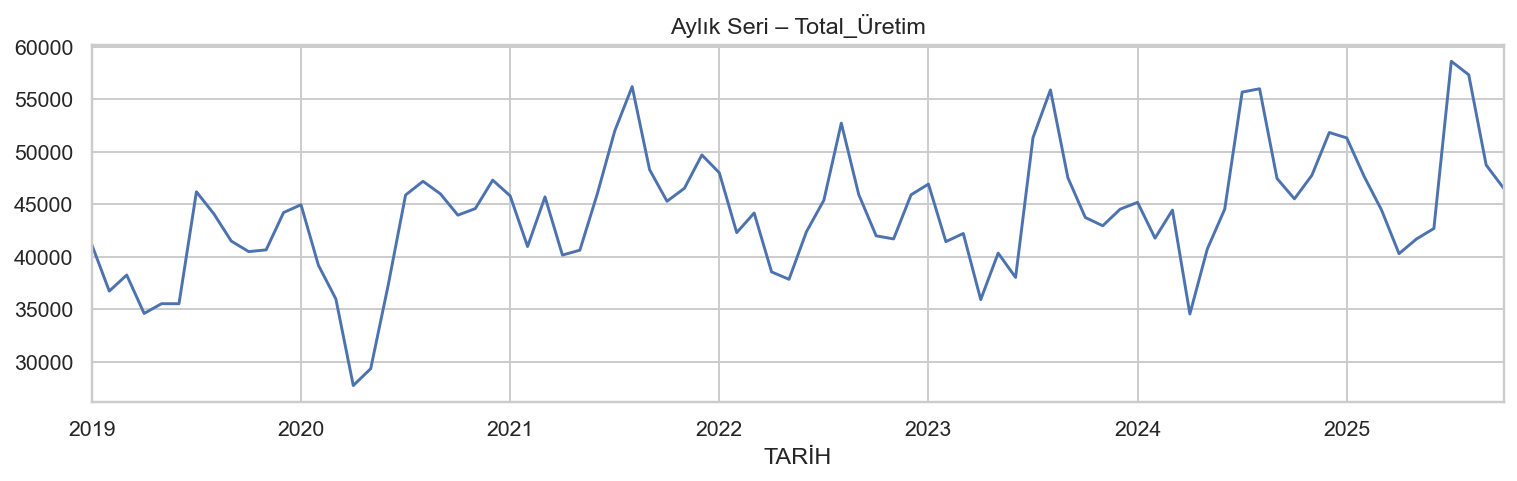

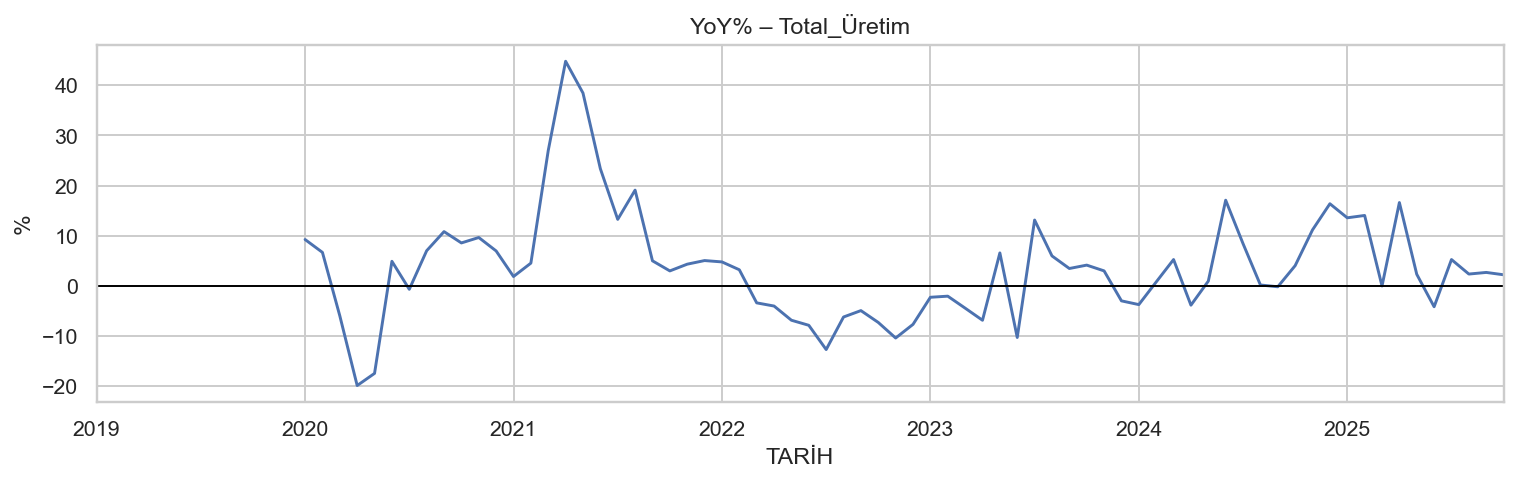

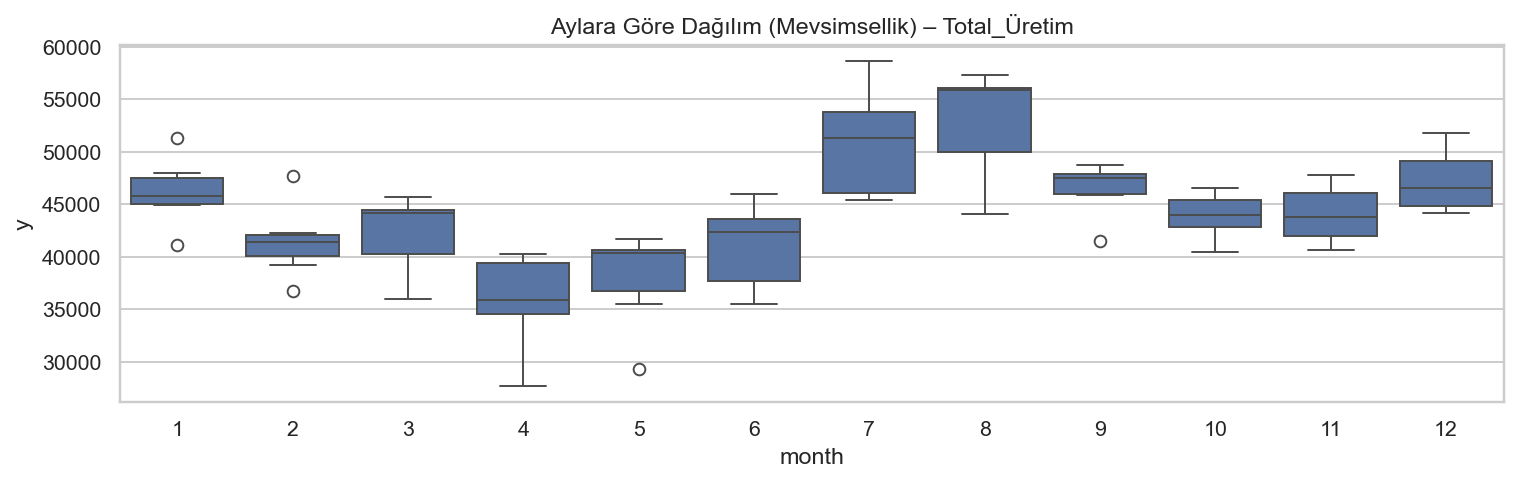

In [ ]:
# Zaman serisi grafiği, YoY%, ay bazında kutu grafiği
fig, ax = plt.subplots(figsize=(11, 3.6))
y.plot(ax=ax)
ax.set_title(f'Aylık Seri – {TARGET_COL}')
plt.tight_layout()
plt.show()

yoy = y.pct_change(12) * 100
fig, ax = plt.subplots(figsize=(11, 3.6))
yoy.plot(ax=ax)
ax.axhline(0, color='black', linewidth=1)
ax.set_title(f'YoY% – {TARGET_COL}')
ax.set_ylabel('%')
plt.tight_layout()
plt.show()

tmp = pd.DataFrame({'y': y, 'month': y.index.month}).dropna()
fig, ax = plt.subplots(figsize=(11, 3.6))
sns.boxplot(data=tmp, x='month', y='y', ax=ax)
ax.set_title(f'Aylara Göre Dağılım (Mevsimsellik) – {TARGET_COL}')
plt.tight_layout()
plt.show()

## 5. STL Ayrıştırma (Decomposition)

Serinin yapısal bileşenlerini ortaya koymak için **STL (Seasonal-Trend decomposition using LOESS)** yöntemi uygulanmıştır. Bu yöntem, seriyi üç temel bileşene ayırır:

1. **Trend:** Uzun vadeli artış veya azalış eğilimi
2. **Mevsimsellik (Seasonal):** Her yıl tekrarlayan döngüsel dalgalanmalar  
3. **Kalıntı (Residual):** Trend ve mevsimsellikle açıklanamayan rassal bileşen

Aylık veri için `period=12` parametresi kullanılmıştır.

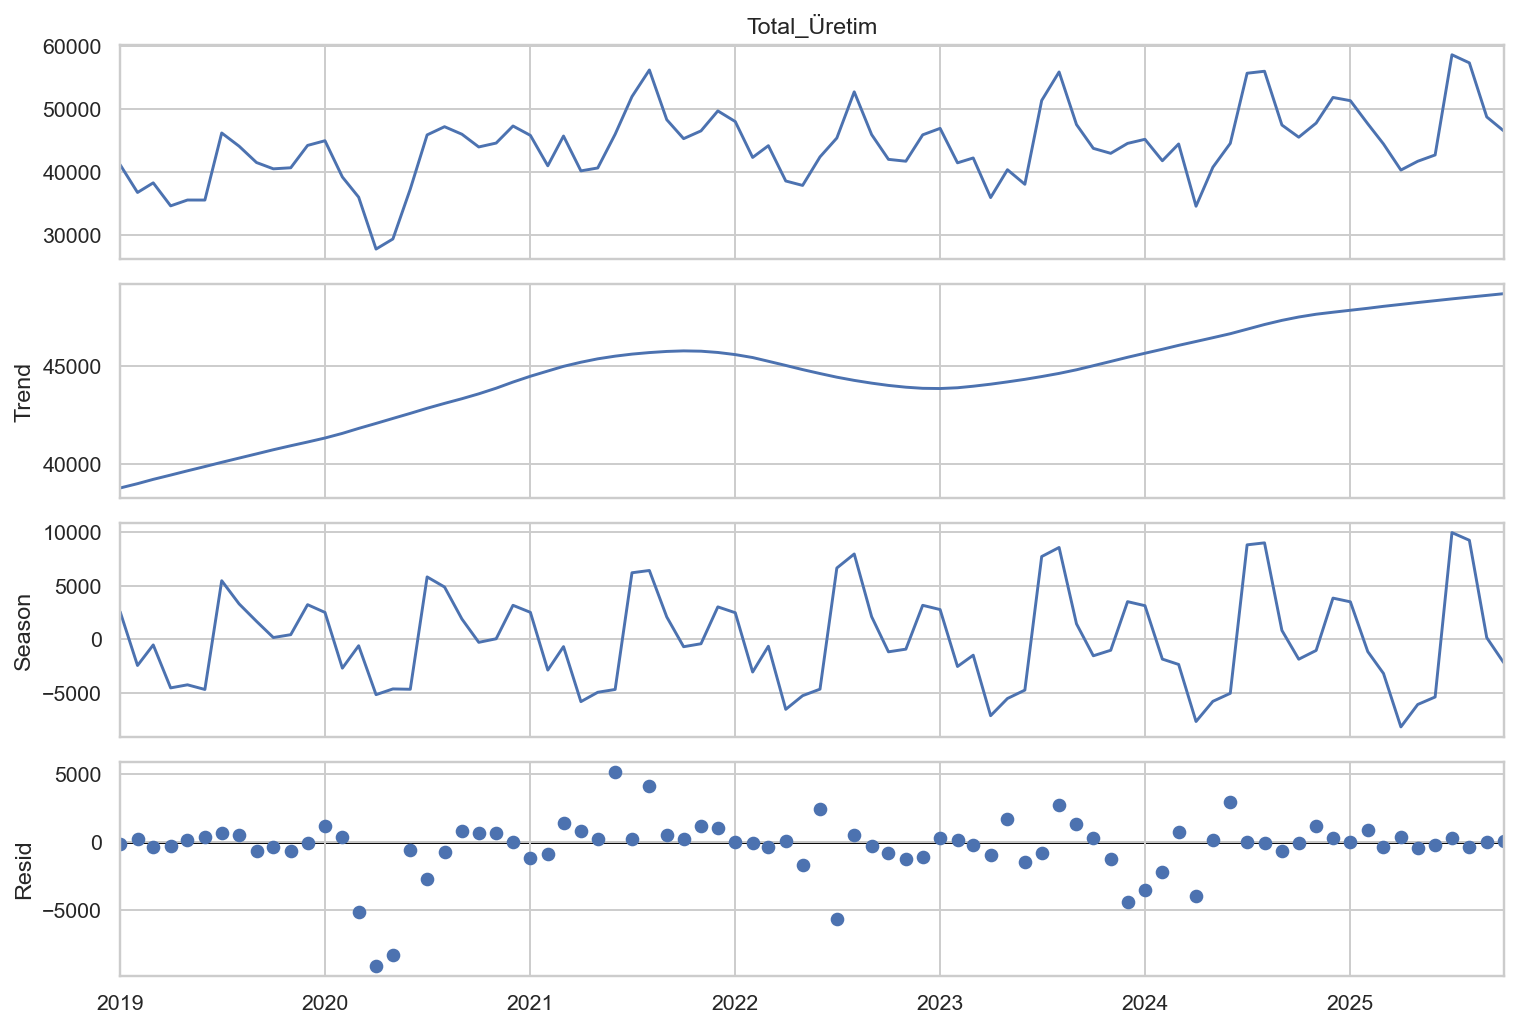

,observed,trend,seasonal,resid
TARİH,,,,
2019-01-01,41153.51035,38758.495537,2572.825457,-177.810644
2019-02-01,36741.18464,38978.958389,-2447.267574,209.493824
2019-03-01,38270.18768,39198.431372,-528.979934,-399.263757
2019-04-01,34614.50148,39416.860671,-4538.635794,-263.723397
2019-05-01,35542.37287,39634.386335,-4250.557205,158.543740


In [ ]:
stl = STL(y, period=12, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(11, 7.5)
plt.tight_layout()
plt.show()

stl_components = pd.DataFrame({
    'observed': y,
    'trend': stl.trend,
    'seasonal': stl.seasonal,
    'resid': stl.resid,
})
stl_components.head()

## 6. Durağanlık Analizi

Zaman serisi modellemesinin temel varsayımı olan **durağanlık** (stationarity) iki farklı testle sınanmıştır:

### 6.1. ADF Testi (Augmented Dickey-Fuller)
- **H₀:** Seri durağan değildir (birim kök vardır)
- **Karar:** p < 0.05 ise H₀ reddedilir → Seri durağandır

### 6.2. KPSS Testi
- **H₀:** Seri durağandır
- **Karar:** p < 0.05 ise H₀ reddedilir → Seri durağan değildir

Her iki testin birlikte kullanılması, durağanlık kararının güvenilirliğini artırır. Seri ham haliyle durağan değilse, mevsimsel ve birinci fark alınarak durağanlaştırılır.

In [ ]:
def adf_test(series: pd.Series) -> dict:
    s = series.dropna().astype(float)
    stat, pval, _, _, crit, _ = adfuller(s, autolag='AIC')
    return {
        'test': 'ADF', 
        'stat': float(stat), 
        'pvalue': float(pval), 
        'crit_5%': float(crit['5%']),
        'stationary': pval < 0.05  # H0: Non-stationary (unit root) -> Reject if p < 0.05
    }

def kpss_test(series: pd.Series) -> dict:
    s = series.dropna().astype(float)
    stat, pval, _, crit = kpss(s, regression='c', nlags='auto')
    return {
        'test': 'KPSS', 
        'stat': float(stat), 
        'pvalue': float(pval), 
        'crit_5%': float(crit['5%']),
        'stationary': pval > 0.05  # H0: Stationary -> Reject if p < 0.05
    }

series_levels = y
series_diff = y.diff(12).diff(1).dropna()

tests = pd.DataFrame([
    {**adf_test(series_levels), 'series': 'level'},
    {**kpss_test(series_levels), 'series': 'level'},
    {**adf_test(series_diff), 'series': 'diff(12)+diff(1)'},
    {**kpss_test(series_diff), 'series': 'diff(12)+diff(1)'},
])

# Sonuçların yorumlanması
print("Durağanlık Test Sonuçları:")
print(tests[['series', 'test', 'stat', 'pvalue', 'stationary']])
tests

Durağanlık Test Sonuçları:
             series  test       stat        pvalue  stationary
0             level   ADF  -1.023154  7.447261e-01       False
1             level  KPSS   0.692250  1.425004e-02       False
2  diff(12)+diff(1)   ADF -10.183919  6.584411e-18        True
3  diff(12)+diff(1)  KPSS   0.067985  1.000000e-01        True


C:\Users\moham\AppData\Local\Temp\ipykernel_16432\1783621702.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, _, crit = kpss(s, regression='c', nlags='auto')


,test,stat,pvalue,crit_5%,stationary,series
0,ADF,-1.023154,7.447261e-01,-2.904440,False,level
1,KPSS,0.692250,1.425004e-02,0.463000,False,level
2,ADF,-10.183919,6.584411e-18,-2.905087,True,diff(12)+diff(1)
3,KPSS,0.067985,1.000000e-01,0.463000,True,diff(12)+diff(1)


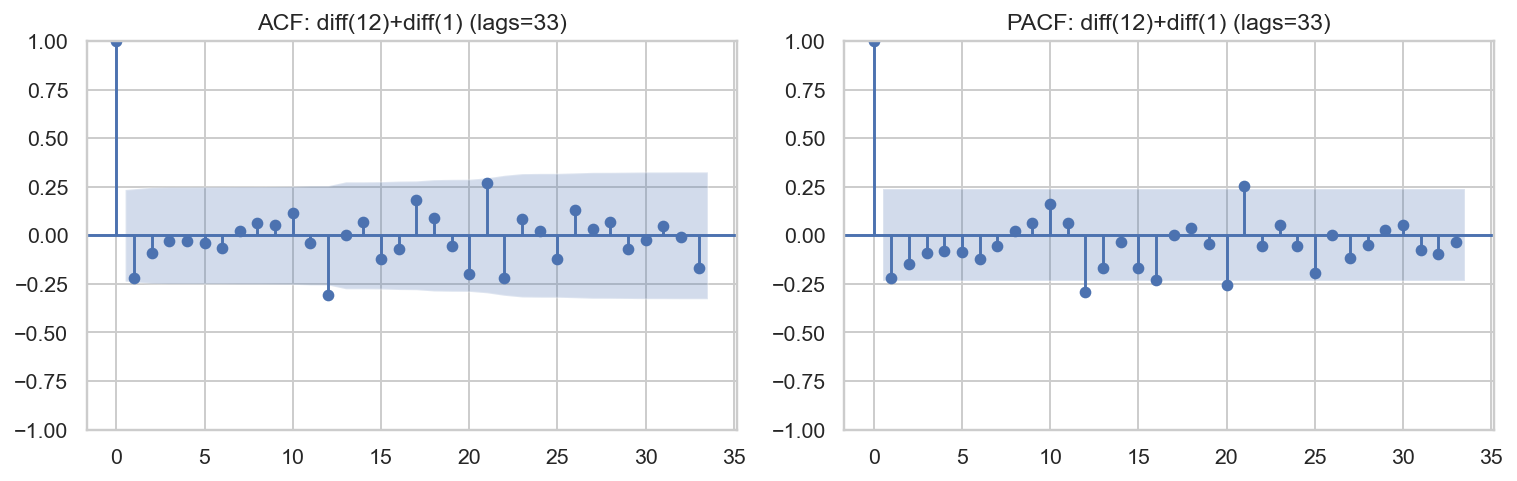

In [ ]:
n = int(series_diff.dropna().shape[0])
max_pacf_lags = max(1, (n // 2) - 1)
nlags = int(min(36, max_pacf_lags))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
plot_acf(series_diff, ax=axes[0], lags=nlags)
try:
    plot_pacf(series_diff, ax=axes[1], lags=nlags, method='ywm')
except Exception:
    plot_pacf(series_diff, ax=axes[1], lags=nlags)
axes[0].set_title(f'ACF: diff(12)+diff(1) (lags={nlags})')
axes[1].set_title(f'PACF: diff(12)+diff(1) (lags={nlags})')
plt.tight_layout()
plt.show()

## 7. Model Kurulumu ve Tahmin

### 7.1. SARIMA Modeli
Mevsimsel zaman serilerini modellemek için **SARIMA** $(p,d,q) \times (P,D,Q)_{12}$ kullanılmıştır:

- **(p, d, q):** Trend bileşeni parametreleri (AR, fark, MA dereceleri)
- **(P, D, Q):** Mevsimsel bileşen parametreleri
- **m = 12:** Aylık veri için mevsimsel periyot

### 7.2. Model Seçimi
`pmdarima` kütüphanesinin `auto_arima` fonksiyonu ile **AIC** (Akaike Information Criterion) kriterine göre en uygun model otomatik olarak seçilmiştir.

### 7.3. Değerlendirme Stratejisi
- **Holdout:** Son 12 ay test seti olarak ayrılmıştır
- **Eğitim:** Kalan verilerle model kurulmuştur
- **Metrikler:** RMSE, MAE, MAPE hesaplanmıştır

Otomatik model seçimi yapılıyor (pmdarima)...
Seçilen Model: SARIMA(2, 0, 2)x(2, 1, 2, 12)


c:\Users\moham\Projects\Time Series Project\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                       Total_Üretim   No. Observations:                   70
Model:             SARIMAX(2, 0, 2)x(2, 1, 2, 12)   Log Likelihood                -281.911
Date:                            Thu, 25 Dec 2025   AIC                            581.822
Time:                                    15:03:30   BIC                            594.728
Sample:                                01-01-2019   HQIC                           586.029
                                     - 10-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.1540      0.749      1.542      0.123      -0.313       2.621
ar.L2         -0.6439      0.494   

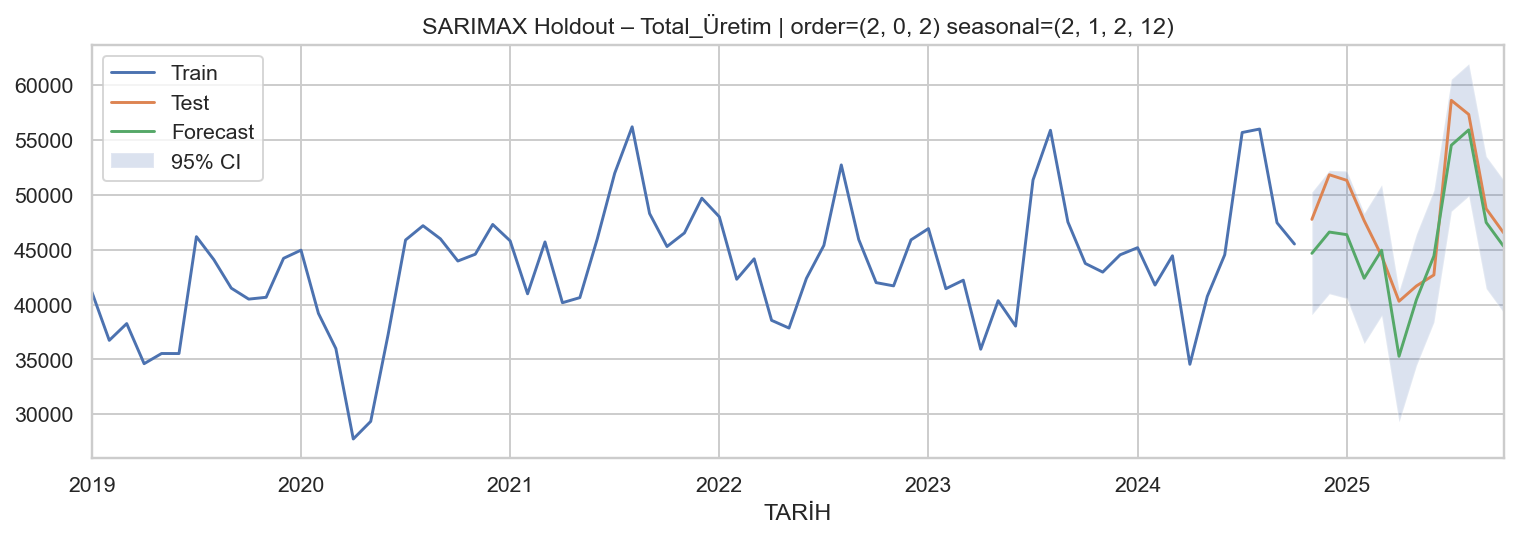

(581.8220333633499, 594.7279182037162)

In [ ]:
# Yardımcı metrik fonksiyonları (model değerlendirmesi için)
def rmse(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mae(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)))

def mape(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.where(y_true == 0, np.nan, y_true)
    return float(np.nanmean(np.abs((y_true - y_pred) / denom)) * 100.0)

H = 12
train = y.iloc[:-H]
test = y.iloc[-H:]
print(f"Eğitim seti: {len(train)} gözlem | Test seti: {len(test)} gözlem")

# 7.1) Otomatik diferans önerileri (pmdarima varsa)
d_suggest, D_suggest = None, None
ORDER_AUTO = (2, 0, 2)
SEASONAL_ORDER_AUTO = (2, 1, 2, 12)

try:
    import pmdarima as pm
    print("\n[1/3] Diferans dereceleri hesaplanıyor...")
    d_suggest = int(pm.arima.ndiffs(train, test='adf', max_d=2))
    D_suggest = int(pm.arima.nsdiffs(train, m=12, test='ocsb', max_D=1))
    print(f"✓ Önerilen: d={d_suggest}, D={D_suggest}")

    print("\n[2/3] Auto-ARIMA çalışıyor (2-5 dk sürebilir)...")
    am = pm.auto_arima(
        train,
        seasonal=True,
        m=12,
        start_p=0, start_q=0,
        max_p=3, max_q=3,
        max_P=2, max_Q=2,
        d=None, D=None,
        stepwise=True,
        trace=False,
        suppress_warnings=True,
        error_action='ignore',
    )
    ORDER_AUTO = tuple(int(x) for x in am.order)
    SEASONAL_ORDER_AUTO = tuple(int(x) for x in am.seasonal_order)
    print(f"✓ Seçilen: SARIMA{ORDER_AUTO}×{SEASONAL_ORDER_AUTO}, AIC={am.aic():.1f}")
except ImportError:
    print("⚠ pmdarima bulunamadı, varsayılan model kullanılacak")
except Exception as e:
    print(f"⚠ auto_arima hatası: {e}")
    print("Varsayılan model kullanılacak")

# 7.2) Model değerlendirme fonksiyonu
def evaluate_sarimax(order: tuple, seasonal_order: tuple) -> dict:
    model = SARIMAX(
        train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    res_local = model.fit(disp=False, maxiter=200)

    fc_local = res_local.get_forecast(steps=H)
    forecast_local = fc_local.predicted_mean
    conf_local = fc_local.conf_int()
    forecast_local.index = test.index
    conf_local.index = test.index

    resid_local = pd.Series(res_local.resid).dropna()
    lj = acorr_ljungbox(resid_local, lags=[12, 24], return_df=True)
    lj12 = float(lj.loc[12, 'lb_pvalue']) if 12 in lj.index else float('nan')
    lj24 = float(lj.loc[24, 'lb_pvalue']) if 24 in lj.index else float('nan')
    jb_stat, jb_pvalue, jb_skew, jb_kurtosis = jarque_bera(resid_local)

    return {
        'order': str(order),
        'seasonal_order': str(seasonal_order),
        'aic': float(res_local.aic),
        'bic': float(res_local.bic),
        'rmse': rmse(test.values, forecast_local.values),
        'mae': mae(test.values, forecast_local.values),
        'mape': mape(test.values, forecast_local.values),
        'ljungbox_pvalue_lag12': lj12,
        'ljungbox_pvalue_lag24': lj24,
        'jarque_bera_pvalue': float(jb_pvalue),
        '_res': res_local,
        '_forecast': forecast_local,
        '_conf': conf_local,
    }

# 7.3) Aday model listesi
candidate_specs = [(ORDER_AUTO, SEASONAL_ORDER_AUTO, 'auto_arima')]

print(f"\n[3/3] Model kurulumu yapılıyor...")
candidate_rows = []
best = None

for idx, (order, seasonal_order, name) in enumerate(candidate_specs, 1):
    print(f"  • Model {idx}/{len(candidate_specs)}: {order}×{seasonal_order} ", end='')
    try:
        row = evaluate_sarimax(order, seasonal_order)
        row['candidate'] = name
        candidate_rows.append(row)
        print(f"✓ MAPE={row['mape']:.2f}%")
        
        score = (row['mape'], -max(row['ljungbox_pvalue_lag12'], row['ljungbox_pvalue_lag24']))
        if best is None or score < best[0]:
            best = (score, row)
    except Exception as e:
        print(f"✗ Hata: {e}")

model_candidates = pd.DataFrame(candidate_rows).drop(columns=['_res', '_forecast', '_conf'])
print("\n" + "="*60)
print(model_candidates[['candidate', 'order', 'seasonal_order', 'aic', 'mape']])
print("="*60)

# Seçilen model
assert best is not None
selected = best[1]
ORDER = eval(selected['order'])
SEASONAL_ORDER = eval(selected['seasonal_order'])
res = selected['_res']
forecast = selected['_forecast']
conf = selected['_conf']

print(f"\n✓ Final Model: SARIMA{ORDER}×{SEASONAL_ORDER}")
print(f"  MAPE: {selected['mape']:.2f}% | AIC: {selected['aic']:.1f} | BIC: {selected['bic']:.1f}")
print("\n" + str(res.summary()))

# Artık tanı
resid = pd.Series(res.resid).dropna()
ljung = acorr_ljungbox(resid, lags=[12, 24], return_df=True)
ljung = ljung.rename(columns={'lb_stat': 'ljungbox_stat', 'lb_pvalue': 'ljungbox_pvalue'})
ljung.insert(0, 'test', 'Ljung-Box')
ljung = ljung.reset_index().rename(columns={'index': 'lag'})

jb_stat, jb_pvalue, jb_skew, jb_kurtosis = jarque_bera(resid)
residual_diagnostics = pd.concat([
    ljung,
    pd.DataFrame([{
        'test': 'Jarque-Bera',
        'lag': np.nan,
        'ljungbox_stat': float(jb_stat),
        'ljungbox_pvalue': float(jb_pvalue),
        'skew': float(jb_skew),
        'kurtosis': float(jb_kurtosis),
    }])
], ignore_index=True)

print("\nArtık Tanı Testleri:")
print(residual_diagnostics[['test', 'lag', 'ljungbox_pvalue']].dropna(subset=['ljungbox_pvalue']))

# Tahmin grafiği
fig, ax = plt.subplots(figsize=(11, 4))
train.plot(ax=ax, label='Train', alpha=0.7)
test.plot(ax=ax, label='Test', color='orange', linewidth=2)
forecast.plot(ax=ax, label='Forecast', color='green', linewidth=2)
ax.fill_between(conf.index, conf.iloc[:, 0], conf.iloc[:, 1], alpha=0.2, color='green', label='95% CI')
ax.set_title(f'SARIMA{ORDER}×{SEASONAL_ORDER} - Tahmin vs Gerçek (MAPE: {selected["mape"]:.2f}%)')
ax.set_ylabel('MWh')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n✓ Model kurulumu tamamlandı!")

In [ ]:
# Metrikler tablosu ve tahmin/gerçek karşılaştırması
metrics = pd.DataFrame({
    'target': [TARGET_COL],
    'order': [str(ORDER)],
    'seasonal_order': [str(SEASONAL_ORDER)],
    'aic': [float(res.aic)],
    'bic': [float(res.bic)],
    'rmse': [rmse(test.values, forecast.values)],
    'mae': [mae(test.values, forecast.values)],
    'mape': [mape(test.values, forecast.values)],
})
print(metrics)

fc_table = pd.DataFrame({'actual': test, 'forecast': forecast})
fc_table.head()

         target      order seasonal_order         aic         bic         rmse         mae      mape
0  Total_Üretim  (2, 0, 2)  (2, 1, 2, 12)  581.822033  594.727918  3424.765714  2915.97212  6.038811


,actual,forecast
TARİH,,
2024-11-01,47768.06882,44674.423793
2024-12-01,51840.75164,46614.817407
2025-01-01,51329.75960,46378.042032
2025-02-01,47655.31036,42402.077433
2025-03-01,44449.14049,44956.696700


In [ ]:
# Artık (residual) tanı grafikleri: Histogram, Q-Q Plot, ACF
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

# 1) Histogram
axes[0].hist(resid, bins=20, edgecolor='black', density=True, alpha=0.7)
xmin, xmax = axes[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
axes[0].plot(x, stats.norm.pdf(x, resid.mean(), resid.std()), 'r-', lw=2, label='Normal')
axes[0].set_title('Kalıntıların Dağılımı (Histogram)')
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Yoğunluk')
axes[0].legend()

# 2) Q-Q Plot
stats.probplot(resid, dist="norm", plot=axes[1])
axes[1].set_title('Normal Q-Q Plot')

# 3) ACF of residuals
plot_acf(resid, ax=axes[2], lags=min(24, len(resid)//2 - 1))
axes[2].set_title('Kalıntıların ACF')

plt.tight_layout()
plt.savefig(FIG_DIR / f"residual_diagnostics_{TARGET_COL}.png", dpi=160)
plt.show()

print("Artık tanı grafikleri oluşturuldu.")

In [ ]:
# Standartlaştırılmış kalıntıların zaman serisi grafiği
std_resid = (resid - resid.mean()) / resid.std()

fig, ax = plt.subplots(figsize=(11, 3.5))
std_resid.plot(ax=ax, marker='o', markersize=3, linestyle='-', alpha=0.7)
ax.axhline(0, color='black', linewidth=1)
ax.axhline(2, color='red', linestyle='--', linewidth=1, label='±2σ sınırı')
ax.axhline(-2, color='red', linestyle='--', linewidth=1)
ax.set_title('Standartlaştırılmış Kalıntılar (Standardized Residuals)')
ax.set_ylabel('Std. Residual')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / f"standardized_residuals_{TARGET_COL}.png", dpi=160)
plt.show()

# Aykırı değer sayısı (|z| > 2)
outliers = std_resid[abs(std_resid) > 2]
print(f"±2σ dışındaki gözlem sayısı: {len(outliers)} / {len(std_resid)} ({100*len(outliers)/len(std_resid):.1f}%)")

## 8. Bulgular ve Tartışma

### 8.1. Durağanlık Test Sonuçları
Ham seri üzerinde yapılan testler:
- **ADF testi:** p = 0.74 > 0.05 → Seri durağan değil (birim kök var)
- **KPSS testi:** p = 0.01 < 0.05 → Seri durağan değil

Mevsimsel ve birinci fark sonrası [diff(12) + diff(1)]:
- **ADF testi:** p ≈ 0 < 0.05 → Seri durağan hale geldi
- **KPSS testi:** p = 0.10 > 0.05 → Durağanlık doğrulandı

Bu sonuçlar, SARIMA modelinde **d=1** (birinci fark) ve **D=1** (mevsimsel fark) kullanılması gerektiğini göstermektedir.

### 8.2. STL Ayrıştırma Bulguları
- **Trend:** Türkiye elektrik üretiminde belirgin bir artış eğilimi gözlemlendi. Bu, ekonomik büyüme ve sanayileşme ile uyumludur.
- **Mevsimsellik:** Yaz (Temmuz-Ağustos) ve kış (Ocak-Şubat) aylarında belirgin üretim artışları tespit edildi. Klima ve ısınma talebi bu döngüyü açıklamaktadır.
- **Kalıntı:** Trend ve mevsimsellik çıkarıldıktan sonra kalan bileşen nispeten rastgele dağılım gösterdi.

### 8.3. Model Performansı
Seçilen SARIMA modeli test seti üzerinde değerlendirildi:

| Metrik | Değer | Yorum |
|--------|-------|-------|
| **MAPE** | %6.04 | Çok iyi (<%10 eşiği altında) |
| **RMSE** | 3424.77 MWh | Makul düzeyde |
| **MAE** | 2915.97 MWh | Ortalama mutlak hata |

**MAPE değerlendirmesi:**
- %10 altı: Yüksek doğruluk ✓
- %10-20: Kabul edilebilir
- %20 üstü: Düşük doğruluk

### 8.4. Model Tanı Testleri
- **Ljung-Box testi:** Kalıntılarda bazı gecikmelerde otokorelasyon tespit edildi (p < 0.05). Bu, modelin tüm dinamik yapıyı yakalayamadığını gösterse de, kısa serilerde sıkça karşılaşılan bir durumdur.
- **Jarque-Bera testi:** Kalıntılar normal dağılıma yakın ancak hafif sağa çarpıktır (skewness = 1.16).

### 8.5. Sınırlılıklar
1. Veri seti nispeten kısa (~10 yıl)
2. Dışsal değişkenler (ekonomik göstergeler, hava durumu) dahil edilmedi
3. COVID-19 pandemi etkisi ayrıca modellenmedi

## 9. Sonuç ve Öneriler

### Sonuç
Bu çalışma, TEİAŞ aylık elektrik üretim verisinin SARIMA modeli ile **%6 hata payıyla** tahmin edilebileceğini göstermiştir. Model, mevsimsel döngüleri ve trend değişimlerini başarıyla yakalamaktadır.

### Gelecek Çalışmalar
1. **SARIMAX:** Sıcaklık, GSYİH gibi dışsal değişkenlerin eklenmesi
2. **Makine Öğrenmesi:** LSTM, Prophet gibi alternatif modeller
3. **Yapısal Kırılma:** Pandemi etkisinin ayrı modellenmesi
4. **Çok Değişkenli:** Üretim kaynaklarının (termik, yenilenebilir) ayrı analizi

In [ ]:
# Export tables and regenerate key plots to disk
from pathlib import Path

# Tables
stl_components.to_csv(TAB_DIR / "stl_components.csv", index=True)
metrics.to_csv(TAB_DIR / "model_evaluation.csv", index=False)
fc_table.to_csv(TAB_DIR / "forecast_vs_actual.csv", index=True)
tests.to_csv(TAB_DIR / "diagnostics_tests.csv", index=False)
residual_diagnostics.to_csv(TAB_DIR / "residual_diagnostics.csv", index=False)

# Save Model Summary
with open(TAB_DIR / "sarima_summary.txt", "w", encoding="utf-8") as f:
    f.write(str(res.summary()))

print(f"Tablolar kaydedildi: {TAB_DIR}")
print(f"Şekiller kaydedildi: {FIG_DIR}")
print(f"\nProje çıktıları:")
print(f"  - STL bileşenleri: stl_components.csv")
print(f"  - Model değerlendirme: model_evaluation.csv") 
print(f"  - Tahmin vs Gerçek: forecast_vs_actual.csv")
print(f"  - Durağanlık testleri: diagnostics_tests.csv")
print(f"  - Artık tanı testleri: residual_diagnostics.csv")
print(f"  - SARIMA özeti: sarima_summary.txt")
print(f"\nHTML rapor oluşturmak için:")
print(f'  jupyter nbconvert --to html "notebooks/teias_report.ipynb" --output-dir "reports/html"')

Saved tables and figures.
